In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 1**: Searching for contamination sources
I am tasked with detecting likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

- **Optimisation Goal**: Maximise

- **Input**: 2D array. The initial dataset contained 10 observations. 
    - Now the data sets include my 9 weeks of manual and model-driven queries, the dataset now contains 19 data points.

- **All-time best**: 2.80e-06 at [0.472, 0.352] (Week 5)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy')

# New data for Week 9 (Function 1)
X_w9_new_point = np.array([0.472000, 0.332000], dtype=np.float64)
Y_w9_new_point = np.array([1.821028999985549e-8], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w9_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w9_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 1: ", X_unique)
print("Updated Outputs (Y) - Function 1: ", Y_updated)

Updated Inputs (X) - Function 1:  [[0.08250725 0.40348751]
 [0.31269116 0.07872278]
 [0.31940389 0.76295937]
 [0.378447   0.273576  ]
 [0.41043714 0.1475543 ]
 [0.472      0.332     ]
 [0.472361   0.351758  ]
 [0.57432921 0.8798981 ]
 [0.575251   0.879599  ]
 [0.65011406 0.68152635]
 [0.68341817 0.86105746]
 [0.73102363 0.73299988]
 [0.732441   0.040134  ]
 [0.799197   0.803213  ]
 [0.819277   0.694779  ]
 [0.84035342 0.26473161]
 [0.88388983 0.58225397]
 [0.919191   0.838383  ]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1:  [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  1.82102900e-008  2.80463460e-006  1.03307824e-046
  1.46776061e-046 -3.60606264e-003  2.53500115e-040  7.71087511e-016
 -5.11184814e-169  4.75768881e-042 -1.84087865e-029  3.34177101e-124
  6.22985647e-048 -3.04056455e-090  0.00000000e+000]


## **Output Analysis**

- **Comparison**: Week 9 returned an output of 1.84e-29. While this is technically a hit compared to the negative noise of Week 8 (-4.59e-18), it is effectively zero and represents a massive stagnation compared to the Week 5 best (2.8e-06).

- **Real-world Implication**: The detection equipment is still failing to pick up a significant signal. 
    - I am essentially wandering in the "shadows" of the radiation field without hitting a gradient that leads to the source.
    
- **Model/Future Exploration**: The model currently views the search space as a vast, flat plane with microscopic jitter. 
    - Because I haven't seen a value above $10^{-6}$ in four weeks, the GP's uncertainty is growing. 
    - I must abandon the current local search area and force the model to explore a completely different quadrant of the 2D field.

## **Bayesian Optimisation**

- **Changes**: I am incorporating Yeo-Johnson transformation and sticking with a Single Matern 2.5 kernel.

- **Reasoning**: The Yeo-Johnson transformation is ssential here because it compresses the massice numerical range between my negative noise readings and my positive outputs, making the distribution more manageable for the GP.
    - The Matern 2.5 kernel provides the necessary smoothness to model the physical nature of a radiaiton field with the WhiteKernel accounts for the high level sensor noise I am clearly encountering.

In [3]:
# Yeo-Johnson Output Transformation (HEBO style)
# Clips extreme negatives before transforming to avoid numerical issues
Y_clipped = np.clip(Y_updated, -1e10, None)
Y_transformed = power_transform(
    Y_clipped.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

# Single Matern 2.5 kernel — simpler and more stable than multi-kernel for sparse data
kernel = Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)

Original Y:    [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  1.82102900e-008  2.80463460e-006  1.03307824e-046
  1.46776061e-046 -3.60606264e-003  2.53500115e-040  7.71087511e-016
 -5.11184814e-169  4.75768881e-042 -1.84087865e-029  3.34177101e-124
  6.22985647e-048 -3.04056455e-090  0.00000000e+000]
Transformed Y: [ 0.23227013  0.23227013  0.23227013  0.23227013  0.23227013  0.23266349
  0.29326315  0.23227013  0.23227013 -4.24224868  0.23227013  0.23227013
  0.23227013  0.23227013  0.23227013  0.23227013  0.23227013  0.23227013
  0.23227013]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function** - Expected Improvement (EI)
- **Acquisition Function Type**: Expected Improvement (EI) with $\xi=0.1$.

- **Sample Size**: 10,000 points.
    - **Intended Impact and Reasoning**: I have decided to utilize Expected Improvement (EI) with a high exploration parameter ($\xi = 0.1$). 
        - In the previous weeks, the model became overly focused on a small, unproductive region. 
        - By setting a higher $\xi$, I am explicitly telling the acquisition function to ignore small jitters in the current data and prioritize finding a point that offers a substantial improvement over the current maximum.
    
- The intended impact is to break the dead-zone cycle. 
    - If I used a lower $\xi$, the model would likely stay close to the Week 5 best, trying to refine a point that is already exhausted. 
    - By sampling 10,000 points uniformly across the entire 2D space, I am giving the model the widest possible net to find a new gradient. 
        - This shift is necessary because the current local search has failed to produce a signal for nearly a month of simulation time.

In [4]:
def expected_improvement(X, model, y_max, xi=0.1):
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Broad uniform sampling across the entire 0-1 range to restart exploration
X_candidates = np.random.uniform(0, 1, size=(10000, 2))

# Selection based on the transformed max
y_max_trans = np.max(Y_transformed)
ei_values = expected_improvement(X_candidates, model, y_max_trans)
next_query = X_candidates[np.argmax(ei_values)]

print(f'Strategic Week 10 Query (Function 1): {next_query[0]:.6f}-{next_query[1]:.6f}')

Strategic Week 10 Query (Function 1): 0.766420-0.752405


## **Visualisation**

/var/folders/gb/k_dw_jpn7yl2j5x099l7d8840000gp/T/ipykernel_24143/2142449934.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=1, alpha=0.8)


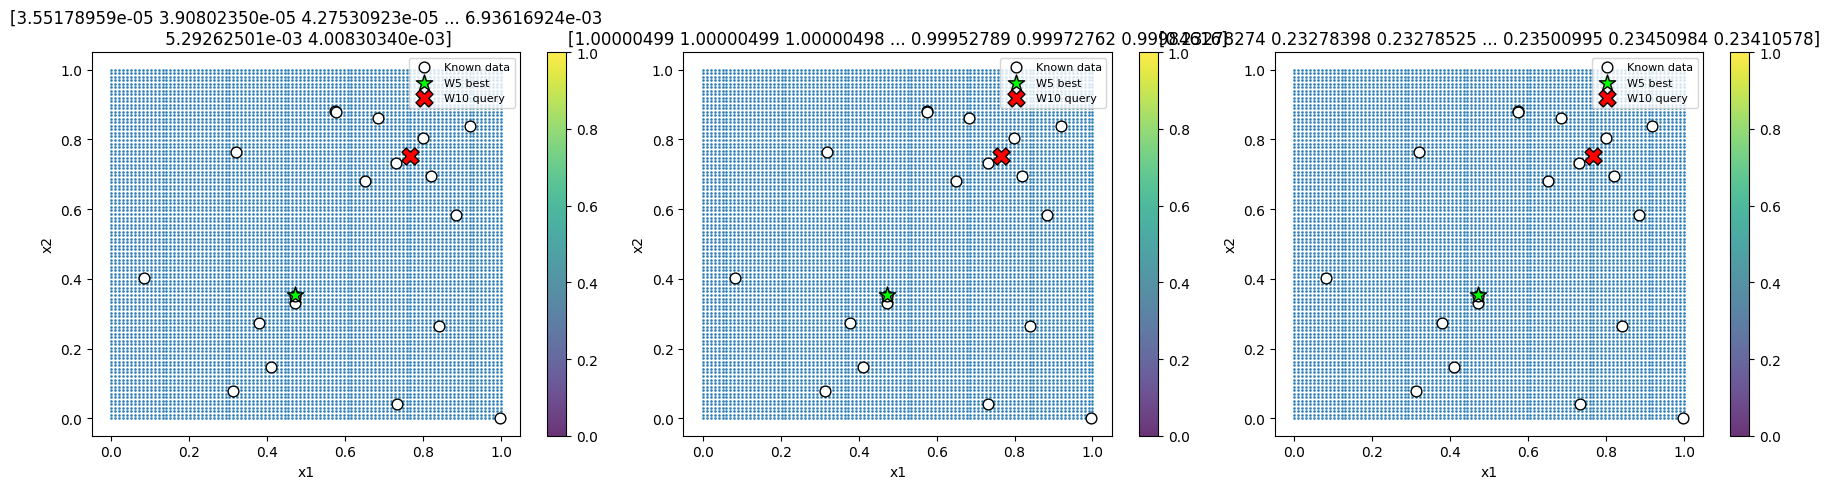

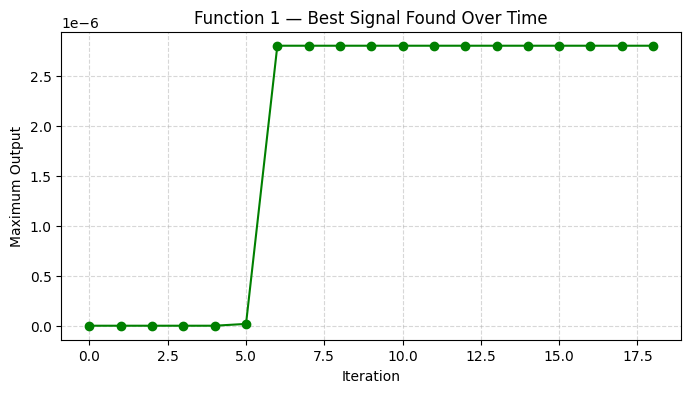

In [7]:
# Build a grid for plotting
x_plot = np.array(np.meshgrid(
    np.linspace(0, 1, 100),
    np.linspace(0, 1, 100)
)).T.reshape(-1, 2)

mu_grid, sigma_grid = model.predict(x_plot, return_std=True)
ei_grid = expected_improvement(x_plot, model, y_max_trans, xi=0.1)

# References
w5_best_coord = [0.472222, 0.352222]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles   = ['GP Mean (Transformed)', 'GP Uncertainty (Sigma)', 'EI Acquisition Surface']
surfaces = [mu_grid, sigma_grid, ei_grid.flatten()]
cmaps    = ['viridis', 'plasma', 'magma']

for ax, surface, title, cmap in zip(axes, titles, surfaces, cmaps):
    # Fixed: Passing 'surface' data to 'c', not the 'title' string
    sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=1, alpha=0.8)
    ax.scatter(X_unique[:, 0], X_unique[:, 1],
               c='white', edgecolors='black', s=60, zorder=5, label='Known data')
    ax.scatter(w5_best_coord[0], w5_best_coord[1],
               c='lime', edgecolors='black', s=150, zorder=6, marker='*', label='W5 best')
    ax.scatter(next_query[0], next_query[1],
               c='red', edgecolors='black', s=150, zorder=7, marker='X', label='W10 query')
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Progress plot
running_max = np.maximum.accumulate(Y_updated)
plt.figure(figsize=(8, 4))
plt.plot(running_max, marker='o', color='green')
plt.title('Function 1 — Best Signal Found Over Time')
plt.xlabel('Iteration')
plt.ylabel('Maximum Output')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()